## NAME: Odilon Ligan & Nick Snyder



In [164]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)

In [3]:
# Load the dataset

# load data set from https://raw.githubusercontent.com/MattDBailey/ANOP330/refs/heads/main/Data/BucknellLendingClubHistoricalData.csv
df = pd.read_csv('https://raw.githubusercontent.com/MattDBailey/ANOP330/refs/heads/main/Data/BucknellLendingClubHistoricalData.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (50000, 29)


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,fico_range_high,fico_range_low,revol_bal,revol_util,total_pymnt,last_pymnt_d,recoveries,loan_length,term_num,ret_PESS
0,44756846,10000,10000,36 months,9.9,322.63,B,10+ years,MORTGAGE,43717.0,...,794,790,59708,19.0,11485.6780,2017-06-01,0.0,26.021069,36,4.952260
1,99480680,34050,34050,60 months,28.6,1074.40,F,10+ years,MORTGAGE,85000.0,...,699,695,16779,76.0,41436.5400,2017-12-01,0.0,9.035093,60,4.338643
2,88321792,9600,9600,36 months,10.4,311.98,B,< 1 year,OWN,37000.0,...,684,680,10148,48.0,10528.5460,2017-09-01,0.0,13.010534,36,3.224118
3,58401079,5000,5000,36 months,9.9,161.32,B,3 years,MORTGAGE,120000.0,...,674,670,14607,38.0,5480.6100,2016-10-01,0.0,13.010534,36,3.204066
4,92749250,9000,9000,36 months,17.9,325.33,D,< 1 year,RENT,70000.0,...,664,660,5344,66.0,10473.4795,2017-11-01,0.0,11.992033,36,5.457331


In [4]:
 #Quick EDA report
def report(df):
    col, d_type, uniques, n_uniques, n_nulls, size = [], [], [], [], [], []
    for i in df.columns:
        col.append(i)
        d_type.append(df[i].dtypes)
        uniques.append(df[i].unique()[:5])
        n_uniques.append(df[i].nunique())
        n_nulls.append(df[i].isnull().sum())
        size.append(df[i].size)
    return pd.DataFrame({'Column': col, 'd_type': d_type, 'unique_sample': uniques,
                         'n_uniques': n_uniques, 'n_nulls': n_nulls, 'size': size})

pd.set_option('display.max_rows', 50)
report(df)

,Column,d_type,unique_sample,n_uniques,n_nulls,size
0,id,int64,"[44756846, 99480680, 88321792, 58401079, 92749...",50000,0,50000
1,loan_amnt,int64,"[10000, 34050, 9600, 5000, 9000]",1298,0,50000
2,funded_amnt,int64,"[10000, 34050, 9600, 5000, 9000]",1299,0,50000
3,term,object,"[ 36 months, 60 months]",2,0,50000
4,int_rate,float64,"[9.9, 28.6, 10.4, 17.9, 20.9]",220,0,50000
5,installment,float64,"[322.63, 1074.4, 311.98, 161.32, 325.33]",19095,0,50000
6,grade,object,"[B, F, D, E, A]",7,0,50000
7,emp_length,object,"[10+ years, < 1 year, 3 years, 8 years, 2 years]",11,2908,50000
8,home_ownership,object,"[MORTGAGE, OWN, RENT, ANY, OTHER]",6,0,50000
9,annual_inc,float64,"[43717.0, 85000.0, 37000.0, 120000.0, 70000.0]",5063,0,50000


In [5]:
#Remove Leakage & Useless Columns
drop_cols = [
    "id",
    "funded_amnt",
    "total_pymnt",
    "recoveries",
    "last_pymnt_d",
    "loan_length",
    "term"
]

df = df.drop(columns=drop_cols, errors='ignore')
df.shape

(50000, 22)

loan_status
Fully Paid     39987
Charged Off    10013
Name: count, dtype: int64


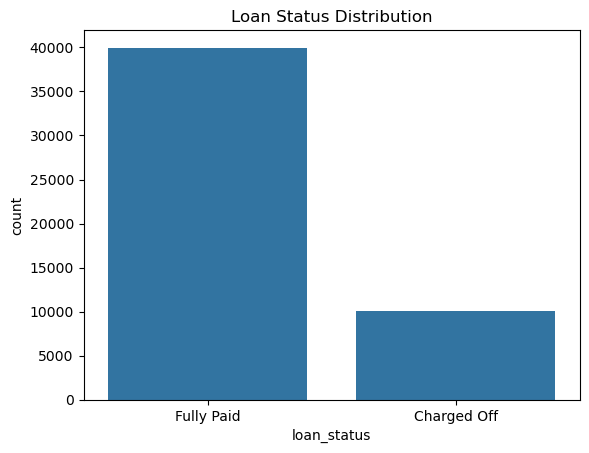

In [6]:
#Explore Target Distributions
print(df["loan_status"].value_counts())
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

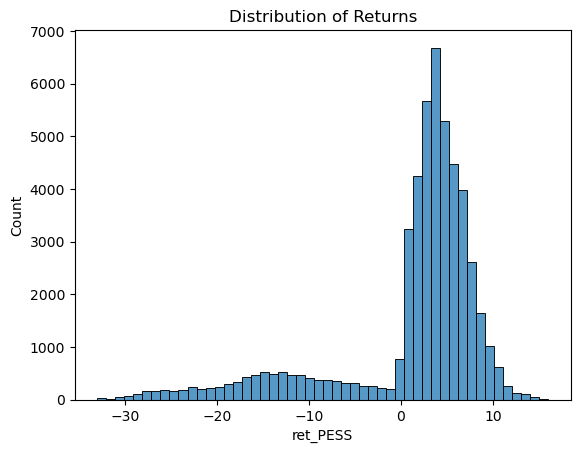

In [7]:
sns.histplot(df["ret_PESS"], bins=50)
plt.title("Distribution of Returns")
plt.show()

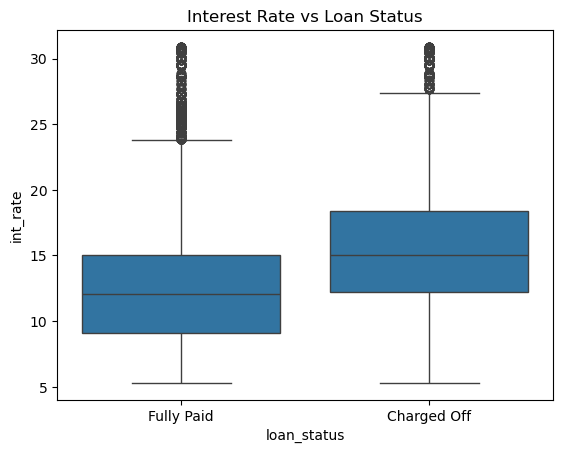

In [8]:
#RELATIONSHIP EXPLORATION
sns.boxplot(x="loan_status", y="int_rate", data=df)
plt.title("Interest Rate vs Loan Status")
plt.show()

*   Higher interest loans default more
*   Suggests risk-based pricing


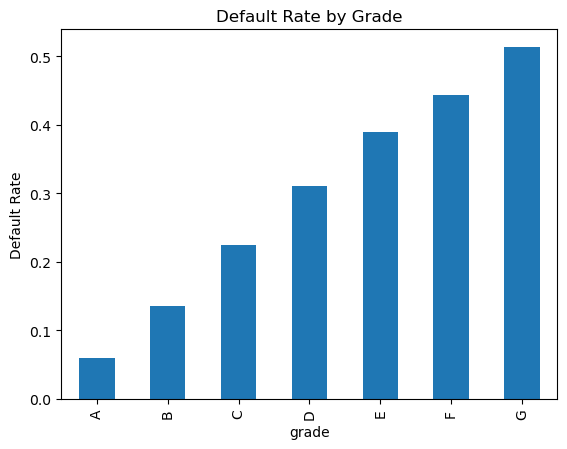

In [9]:
default_rate = df.groupby("grade")["loan_status"].apply(
    lambda x: (x == "Charged Off").mean()
)
default_rate.plot(kind="bar")
plt.title("Default Rate by Grade")
plt.ylabel("Default Rate")
plt.show()

*   Lower grades (E, F, G) : much higher default rates
*   shows that lower grades have relatively more charged-off loans compared to fully paid loans

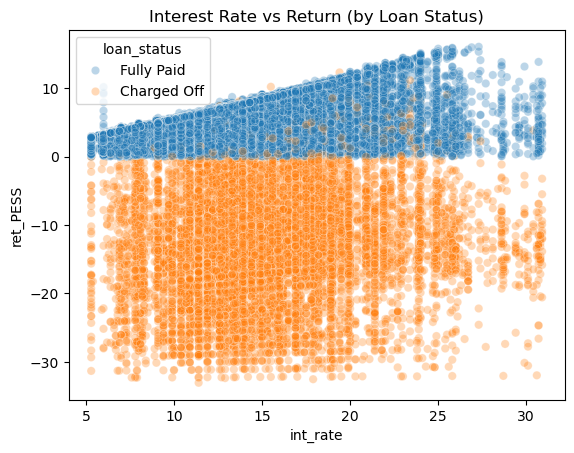

In [10]:
sns.scatterplot(
    x="int_rate",
    y="ret_PESS",
    hue="loan_status",
    data=df,
    alpha=0.3
)
plt.title("Interest Rate vs Return (by Loan Status)")
plt.show()

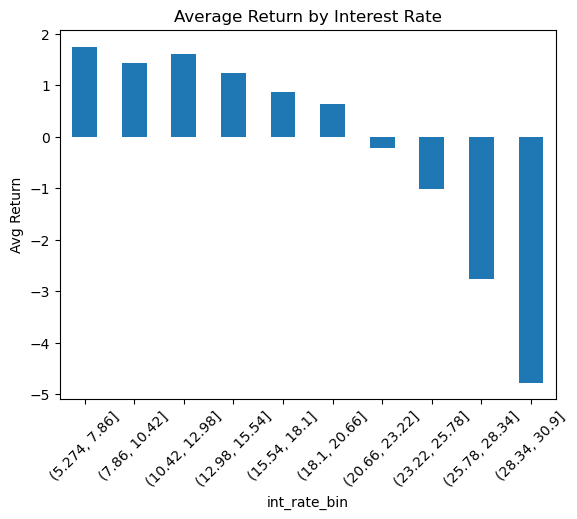

In [11]:
df["int_rate_bin"] = pd.cut(df["int_rate"], bins=10)

avg_return = df.groupby("int_rate_bin")["ret_PESS"].mean()

avg_return.plot(kind="bar")
plt.title("Average Return by Interest Rate")
plt.ylabel("Avg Return")
plt.xticks(rotation=45)
plt.show()

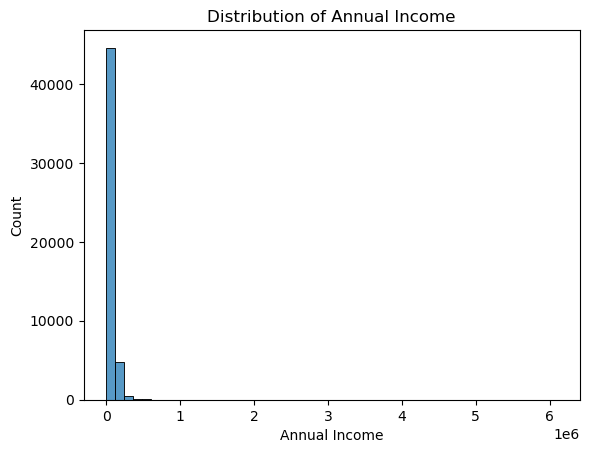

In [12]:
sns.histplot(df["annual_inc"], bins=50)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.show()

The distribution of annual income is highly right-skewed, with a small number of very high-income outliers. Applying a log transformation will reveals a more symmetric distribution, indicating that most borrowers fall within a relatively concentrated income range.

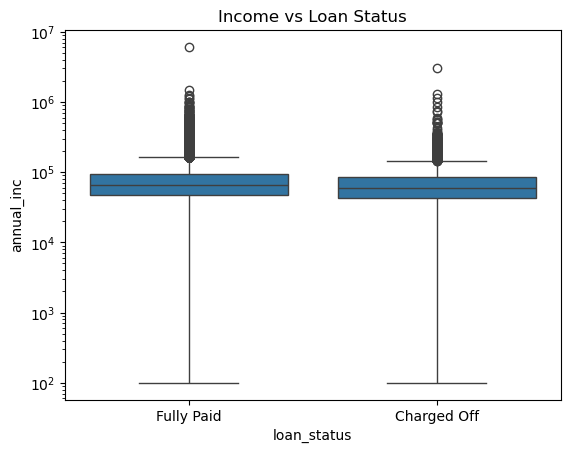

In [13]:
sns.boxplot(x="loan_status", y="annual_inc", data=df)
plt.yscale("log")
plt.title("Income vs Loan Status")
plt.show()

Annual income shows little separation between fully paid and charged-off loans, suggesting that income alone is not much of a strong predictor of default risk.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   loan_amnt            50000 non-null  int64   
 1   int_rate             50000 non-null  float64 
 2   installment          50000 non-null  float64 
 3   grade                50000 non-null  object  
 4   emp_length           47092 non-null  object  
 5   home_ownership       50000 non-null  object  
 6   annual_inc           50000 non-null  float64 
 7   verification_status  50000 non-null  object  
 8   issue_d              50000 non-null  object  
 9   loan_status          50000 non-null  object  
 10  purpose              50000 non-null  object  
 11  dti                  50000 non-null  float64 
 12  delinq_2yrs          50000 non-null  float64 
 13  earliest_cr_line     50000 non-null  object  
 14  open_acc             50000 non-null  float64 
 15  pub_rec            

In [15]:
# Handle missing values
df['emp_length'] = df['emp_length'].fillna('10+ years')

In [16]:
# Log transform income
df['annual_inc'] = np.log1p(df['annual_inc'])

# Convert earliest credit line to "credit age"
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


df['credit_age'] = (df['issue_d'] - df['earliest_cr_line']).dt.days

In [17]:

# Convert target
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df = df.drop(columns=['loan_status'])

In [18]:
df['dti'].describe()

count    50000.000000
mean        18.343213
std         11.258257
min          0.000000
25%         11.870000
50%         17.730000
75%         24.080000
max        999.000000
Name: dti, dtype: float64

In [128]:
df['revol_bal'].describe()

count     49982.000000
mean      16450.821676
std       22296.095259
min           0.000000
25%        6046.250000
50%       11204.500000
75%       19854.000000
max      959754.000000
Name: revol_bal, dtype: float64

In [130]:
df['revol_bal'] = np.log1p(df['revol_bal'])

In [131]:
df['revol_bal'].describe()

count    49982.000000
mean         9.210636
std          1.199121
min          0.000000
25%          8.707359
50%          9.324160
75%          9.896211
max         13.774433
Name: revol_bal, dtype: float64

In [129]:
df['revol_util'].describe()

count    49982.000000
mean        51.579587
std         24.471208
min          0.000000
25%         33.000000
50%         52.000000
75%         70.000000
max        152.000000
Name: revol_util, dtype: float64

In [19]:
# Handle extreme outlier
df = df[df['dti'] < 100]  # remove crazy outlier like 999

In [20]:
# FICO average
df['fico_avg'] = (df['fico_range_high'] + df['fico_range_low']) / 2
df = df.drop(columns=['fico_range_high', 'fico_range_low'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49982 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   loan_amnt            49982 non-null  int64         
 1   int_rate             49982 non-null  float64       
 2   installment          49982 non-null  float64       
 3   grade                49982 non-null  object        
 4   emp_length           49982 non-null  object        
 5   home_ownership       49982 non-null  object        
 6   annual_inc           49982 non-null  float64       
 7   verification_status  49982 non-null  object        
 8   issue_d              49982 non-null  datetime64[ns]
 9   purpose              49982 non-null  object        
 10  dti                  49982 non-null  float64       
 11  delinq_2yrs          49982 non-null  float64       
 12  earliest_cr_line     49982 non-null  datetime64[ns]
 13  open_acc             49982 non-null 

In [132]:
#sort by time
df = df.sort_values(by='issue_d')

#Choose split point (70% train, 30% test)
split_index = int(len(df) * 0.7)

#split dataframe
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

In [40]:
print(train_df['issue_d'].min(), train_df['issue_d'].max())
print(test_df['issue_d'].min(), test_df['issue_d'].max())

2009-01-01 00:00:00 2016-03-01 00:00:00
2016-03-01 00:00:00 2018-12-01 00:00:00


In [134]:
# Targets
y_class = df['default']
train_y = train_df['ret_PESS']
test_y  = test_df['ret_PESS']

# Predictors
drop_cols = [
    'default',
    'ret_PESS',
    'issue_d',
    'earliest_cr_line',
    'installment',
    'fico_range_high',
    'fico_range_low'
]

train_X = train_df.drop(columns=drop_cols, errors='ignore')
test_X  = test_df.drop(columns=drop_cols, errors='ignore')

In [135]:
print(train_X.columns.tolist())

['loan_amnt', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'term_num', 'int_rate_bin', 'credit_age', 'fico_avg']


In [136]:
train_X = pd.get_dummies(train_X, drop_first=True)
test_X  = pd.get_dummies(test_X, drop_first=True)

# Make columns match
train_X, test_X = train_X.align(test_X, join='left', axis=1, fill_value=0)

print(train_X.shape, test_X.shape)

(34987, 56) (14995, 56)


In [160]:
print(train_X.columns.tolist())

['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'term_num', 'credit_age', 'fico_avg', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'emp_length_10+ years', 'emp_length_2 years', 'emp_length_3 years', 'emp_length_4 years', 'emp_length_5 years', 'emp_length_6 years', 'emp_length_7 years', 'emp_length_8 years', 'emp_length_9 years', 'emp_length_< 1 year', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'int_rate_bin_(7.86, 10.42]', 'int_rate_bin_(10.42, 12.98]', 'int_rate_bin_(12.98, 15.54]', 'int_rate_bi

In [43]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

tscv = TimeSeriesSplit(n_splits=5)

In [91]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None]
}


rf = RandomForestRegressor(random_state=42)

In [137]:

rf = RandomForestRegressor(random_state=42)

grid2 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,  
    scoring='r2',
    n_jobs=-1
)

grid2.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [138]:
print("Best Params:", grid2.best_params_)
print("Best CV R2:", grid2.best_score_)

Best Params: {'max_depth': 5, 'n_estimators': 200}
Best CV R2: -0.01050095789659622


In [139]:
baseline_pred = np.full(len(test_y), train_y.mean())


baseline_rmse = np.sqrt(mean_squared_error(test_y, baseline_pred))

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 9.82739876513139


In [140]:
best_model = grid2.best_estimator_

# Predictions
train_pred = best_model.predict(train_X)
test_pred = best_model.predict(test_X)

from sklearn.metrics import mean_squared_error
import numpy as np

test_rmse = np.sqrt(mean_squared_error(test_y, test_pred))

print("Final Test RMSE:", test_rmse)

Final Test RMSE: 9.738273311271099


In [141]:

# CV metrics (time-aware)
cv_mae = -cross_val_score(best_model, train_X, train_y, cv=tscv, scoring='neg_mean_absolute_error')
cv_rmse = np.sqrt(-cross_val_score(best_model, train_X, train_y, cv=tscv, scoring='neg_mean_squared_error'))
cv_r2 = cross_val_score(best_model, train_X, train_y, cv=tscv, scoring='r2')

# Formatting helper
def fmt(val):
    return f"{val:,.3f}"

# Table width
w = 14
sep = "-" * (10 + 3 * w)

print("=" * (10 + 3 * w))
print("MODEL EVALUATION (Train vs CV vs Test)")
print("=" * (10 + 3 * w))

print(f"{'Metric':<10s} {'Train':>{w}s} {'CV':>{w}s} {'Test':>{w}s}")
print(sep)

# MAE
print(f"{'MAE':<10s} {fmt(mean_absolute_error(train_y, train_pred)):>{w}s} {fmt(cv_mae.mean()):>{w}s} {fmt(mean_absolute_error(test_y, test_pred)):>{w}s}")

# RMSE
print(f"{'RMSE':<10s} {fmt(np.sqrt(mean_squared_error(train_y, train_pred))):>{w}s} {fmt(cv_rmse.mean()):>{w}s} {fmt(np.sqrt(mean_squared_error(test_y, test_pred))):>{w}s}")

# R²
print(f"{'R²':<10s} {r2_score(train_y, train_pred):{w}.4f} {cv_r2.mean():{w}.4f} {r2_score(test_y, test_pred):{w}.4f}")

print(sep)

MODEL EVALUATION (Train vs CV vs Test)
Metric              Train             CV           Test
----------------------------------------------------
MAE                 4.804          4.588          5.669
RMSE                7.295          7.418          9.738
R²                 0.0362        -0.0105        -0.1304
----------------------------------------------------


In [142]:
results = pd.DataFrame({
    'pred': test_pred,
    'actual': test_y
})

results = results.sort_values(by='pred', ascending=False)

top_20 = results.head(int(0.2 * len(results)))

print("Top 20% Avg Return:", top_20['actual'].mean())
print("Overall Avg Return:", results['actual'].mean())

Top 20% Avg Return: -1.129952938447816
Overall Avg Return: -1.3213497936434444


In [143]:
for p in [0.1, 0.2, 0.3, 0.5]:
    top = results.head(int(p * len(results)))
    print(f"Top {int(p*100)}%:", top['actual'].mean())

Top 10%: -0.9844983132161442
Top 20%: -1.129952938447816
Top 30%: -1.0496427959045576
Top 50%: -0.8242458507733761


In [71]:
random = results.sample(frac=1)

top_rand = random.head(int(0.2 * len(random)))

print("Random Top 20%:", top_rand['actual'].mean())

Random Top 20%: -1.4666182961746248


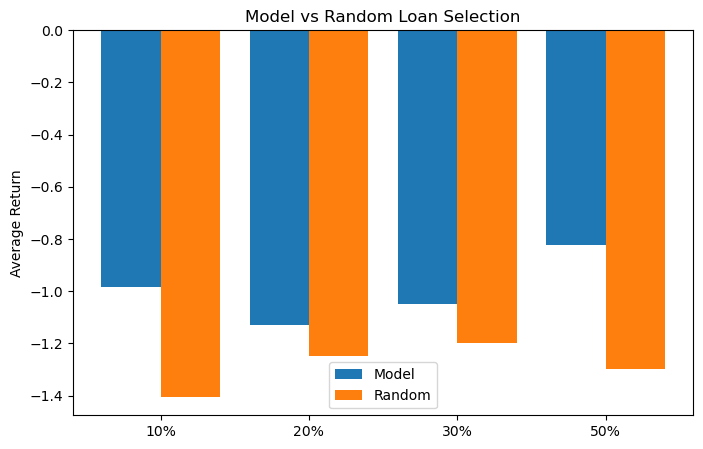

In [144]:
# Model cumulative

percentiles = [0.1, 0.2, 0.3, 0.5]

model_vals = []
random_vals = []

for p in percentiles:
    top = results.head(int(p * len(results)))
    model_vals.append(top['actual'].mean())

    rand = results.sample(frac=1)
    top_rand = rand.head(int(p * len(results)))
    random_vals.append(top_rand['actual'].mean())

plt.figure(figsize=(8,5))
x = np.arange(len(percentiles))

plt.bar(x - 0.2, model_vals, width=0.4, label='Model')
plt.bar(x + 0.2, random_vals, width=0.4, label='Random')

plt.xticks(x, [f"{int(p*100)}%" for p in percentiles])
plt.ylabel("Average Return")
plt.title("Model vs Random Loan Selection")
plt.legend()
plt.show()

In [145]:
# Fit StandardScaler on TRAINING data only — then transform both sets
scaler = StandardScaler()
scaler.fit(train_X)   # learn mean and std from training data ONLY

train_X_std = pd.DataFrame(scaler.transform(train_X), columns=train_X.columns, index=train_X.index)
test_X_std  = pd.DataFrame(scaler.transform(test_X),  columns=test_X.columns,  index=test_X.index)

In [146]:
lm = LinearRegression()
lm.fit(train_X_std, train_y)
cv_train_r2_lr     =  cross_val_score(lm,     train_X_std,     train_y, cv=5, scoring='r2')
cv_test_r2_lr     =  cross_val_score(lm,     test_X_std,     test_y, cv=5, scoring='r2')
print(f"Linear Regression R² on Training Data: {cv_train_r2_lr.mean():>16.4f}")
#print(f"Linear Regression R² on Test Data:     {cv_test_r2_lr.mean():>16.4f}")
print()

lr_train_pred = lm.predict(train_X_std)
lr_test_pred  = lm.predict(test_X_std)
print(f"Test prediction range:  ${lr_test_pred.min():,.0f}  to  ${lr_test_pred.max():,.0f}")
print(f"Actual  range:     ${test_y.min():,.0f}  to  ${test_y.max():,.0f}")
print()
# Proper test evaluation
print(f"Linear Regression Test R²: {r2_score(test_y, lr_test_pred):.4f}")

Linear Regression R² on Training Data:          -0.0030

Test prediction range:  $-7  to  $7
Actual  range:     $-33  to  $15

Linear Regression Test R²: -0.1381


In [147]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline

poly_lasso = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', LassoCV(cv=tscv, random_state=42))
])

# Fit
poly_lasso.fit(train_X_std, train_y)

#Predictions
poly_train_pred = poly_lasso.predict(train_X_std)
poly_test_pred = poly_lasso.predict(test_X_std)

# Scores
print("Train R²:", r2_score(train_y, poly_train_pred))
print("Test R²:", r2_score(test_y, poly_test_pred))
print("Best alpha:", poly_lasso.named_steps['lasso'].alpha_)

# print(f"Best alpha chosen by LassoCV: {lasso_cv.alpha_:.4f}")
# print(f"Intercept: ${lasso_cv.intercept_:,.2f}")
# print(f"R² on Training: {lasso_cv.score(train_X_std, train_y):.4f}")
# print(f"R² on Test:     {lasso_cv.score(test_X_std, test_y):.4f}\n")

Train R²: 0.022472982317675583
Test R²: -0.1317246418912894
Best alpha: 0.14485843949913002


In [148]:
print(f"Test prediction range:  ${test_pred.min():,.0f}  to  ${test_pred.max():,.0f}")
print(f"Actual  range:     ${test_y.min():,.0f}  to  ${test_y.max():,.0f}")

Test prediction range:  $-11  to  $4
Actual  range:     $-33  to  $15


In [149]:
# LassoCV
lasso_cv = LassoCV(cv=tscv, random_state=42)

# Fit
lasso_cv.fit(train_X_std, train_y)

# Predictions
lasso_train_pred = lasso_cv.predict(train_X_std)
lasso_test_pred = lasso_cv.predict(test_X_std)

# Scores
print("Train R²:", r2_score(train_y, lasso_train_pred))
print("Test R²:", r2_score(test_y, lasso_test_pred))
print("Best alpha:", lasso_cv.alpha_)

Train R²: 0.022124072060046296
Test R²: -0.1271703517816687
Best alpha: 0.03881132023701282


In [150]:
# Coefficient comparison: plain LR vs. LassoCV
coef_compare = pd.DataFrame({
    'Predictor': train_X.columns,
    'LR (std)': lm.coef_,
    'LassoCV': lasso_cv.coef_
})
coef_compare['Lasso Status'] = coef_compare['LassoCV'].apply(
    lambda x: '❌ Removed' if x == 0 else '✅ Kept'
)
coef_compare = coef_compare.sort_values('LassoCV', key=abs, ascending=False).reset_index(drop=True)
pd.options.display.float_format = '{:,.3f}'.format
print(coef_compare.to_string(index=False))
pd.reset_option('display.float_format')

                          Predictor  LR (std)  LassoCV Lasso Status
                           term_num    -0.726   -0.662       ✅ Kept
                                dti    -0.378   -0.356       ✅ Kept
                         revol_util     0.334    0.331       ✅ Kept
                           int_rate     1.256    0.310       ✅ Kept
                home_ownership_RENT    -0.327   -0.281       ✅ Kept
        int_rate_bin_(25.78, 28.34]    -0.307   -0.237       ✅ Kept
                            grade_B    -0.018    0.225       ✅ Kept
                            grade_E    -1.093   -0.191       ✅ Kept
                           fico_avg     0.307    0.184       ✅ Kept
verification_status_Source Verified    -0.131   -0.136       ✅ Kept
        int_rate_bin_(23.22, 25.78]    -0.137   -0.110       ✅ Kept
                         annual_inc     0.183    0.105       ✅ Kept
                 home_ownership_OWN    -0.147   -0.097       ✅ Kept
         int_rate_bin_(28.34, 30.9]    -0.138   

In [152]:
w = 14
sep = "-" * (10 + 6 * w)

print("=" * (10 + 6 * w))
print("MODEL COMPARISON (Returns Prediction)")
print("=" * (10 + 6 * w))

print(f"{'Metric':<10s} "
      f"{'LR Train':>{w}s} {'LR Test':>{w}s} "
      f"{'Lasso Tr':>{w}s} {'Lasso Te':>{w}s} "
      f"{'Poly Tr':>{w}s} {'Poly Te':>{w}s}"
      f"{'RF Tr':>{w}s} {'RF Te':>{w}s}")

print(sep)

# MAE
print(f"{'MAE':<10s} "
      f"{fmt(mean_absolute_error(train_y, lr_train_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(test_y, lr_test_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(train_y, lasso_train_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(test_y, lasso_test_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(train_y, poly_train_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(test_y, poly_test_pred)):>{w}s}"
      f"{fmt(mean_absolute_error(train_y, train_pred)):>{w}s}"
      f"{fmt(mean_absolute_error(test_y, test_pred)):>{w}s}")
 

# RMSE
print(f"{'RMSE':<10s} "
      f"{fmt(np.sqrt(mean_squared_error(train_y, lr_train_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(test_y, lr_test_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(train_y, lasso_train_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(test_y, lasso_test_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(train_y, poly_train_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(test_y, poly_test_pred))):>{w}s}"
      f"{fmt(np.sqrt(mean_squared_error(train_y, train_pred))):>{w}s}"
      f"{fmt(np.sqrt(mean_squared_error(test_y, test_pred))):>{w}s}")

# R²
print(f"{'R²':<10s} "
      f"{r2_score(train_y, lr_train_pred):{w}.4f} "
      f"{r2_score(test_y, lr_test_pred):{w}.4f} "
      f"{r2_score(train_y, lasso_train_pred):{w}.4f} "
      f"{r2_score(test_y, lasso_test_pred):{w}.4f} "
      f"{r2_score(train_y, poly_train_pred):{w}.4f} "
      f"{r2_score(test_y, poly_test_pred):{w}.4f}"
      f"{r2_score(train_y, train_pred):>{w}.4f}"
      f"{r2_score(test_y, test_pred):>{w}.4f}")

print(sep)

MODEL COMPARISON (Returns Prediction)
Metric           LR Train        LR Test       Lasso Tr       Lasso Te        Poly Tr        Poly Te         RF Tr          RF Te
----------------------------------------------------------------------------------------------
MAE                 4.853          5.742          4.859          5.693          4.852          5.677         4.804         5.669
RMSE                7.336          9.771          7.348          9.724          7.347          9.744         7.295         9.738
R²                 0.0254        -0.1381         0.0221        -0.1272         0.0225        -0.1317        0.0362       -0.1304
----------------------------------------------------------------------------------------------


In [153]:
results2 = pd.DataFrame({
    'pred': lasso_test_pred,
    'actual': test_y
})

results2 = results2.sort_values(by='pred', ascending=False)

top_20 = results2.head(int(0.2 * len(results)))

print("Top 20% Avg Return:", top_20['actual'].mean())
print("Overall Avg Return:", results['actual'].mean())

Top 20% Avg Return: -0.26903302961010334
Overall Avg Return: -1.3213497936434444


In [154]:
results = pd.DataFrame({
    'pred': test_pred,
    'actual': test_y
})

results = results.sort_values(by='pred', ascending=False)

top_20_2 = results.head(int(0.2 * len(results)))

print("Top 20% Avg Return:", top_20_2['actual'].mean())
print("Overall Avg Return:", results['actual'].mean())

Top 20% Avg Return: -1.129952938447816
Overall Avg Return: -1.3213497936434444


In [155]:
for p in [0.1, 0.2, 0.3, 0.5]:
    top = results2.head(int(p * len(results2)))
    print(f"Top {int(p*100)}%:", top['actual'].mean())

Top 10%: -0.1827432738405603
Top 20%: -0.26903302961010334
Top 30%: -0.49220195786387283
Top 50%: -0.6900868671273442


In [156]:
for p in [0.1, 0.2, 0.3, 0.5]:
    top = results.head(int(p * len(results)))
    print(f"Top {int(p*100)}%:", top['actual'].mean())

Top 10%: -0.9844983132161442
Top 20%: -1.129952938447816
Top 30%: -1.0496427959045576
Top 50%: -0.8242458507733761


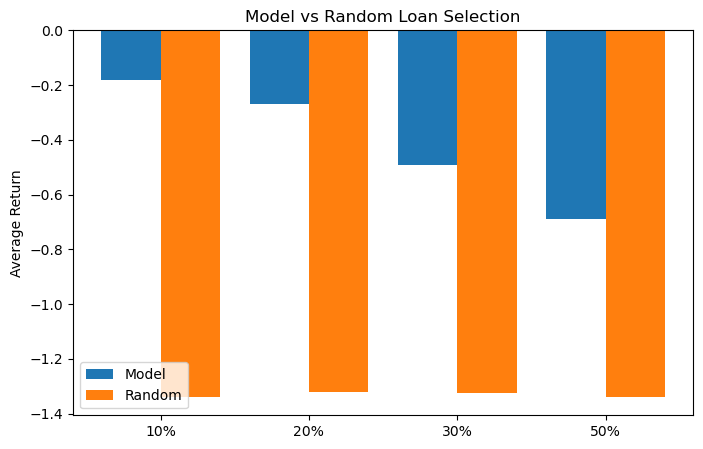

In [157]:
percentiles = [0.1, 0.2, 0.3, 0.5]

model_vals = []
random_vals = []

for p in percentiles:
    top = results2.head(int(p * len(results2)))
    model_vals.append(top['actual'].mean())

    # ✅ Random (averaged over many runs)
    temp_random_vals = []

    for _ in range(50):  # repeat 50 times
        rand = results2.sample(frac=1)
        top_rand = rand.head(int(p * len(results2)))
        temp_random_vals.append(top_rand['actual'].mean())

    random_avg = np.mean(temp_random_vals)
    random_vals.append(random_avg)

plt.figure(figsize=(8,5))
x = np.arange(len(percentiles))

plt.bar(x - 0.2, model_vals, width=0.4, label='Model')
plt.bar(x + 0.2, random_vals, width=0.4, label='Random')

plt.xticks(x, [f"{int(p*100)}%" for p in percentiles])
plt.ylabel("Average Return")
plt.title("Model vs Random Loan Selection")
plt.legend()
plt.show()

In [158]:
train_class_y = train_df['default']
test_class_y  = test_df['default']

# Predictors
drop_cols = [
    'default',
    'ret_PESS',
    'issue_d',
    'earliest_cr_line',
    'installment',
    'fico_range_high',
    'fico_range_low'
]

train_class_X = train_df.drop(columns=drop_cols, errors='ignore')
test_class_X  = test_df.drop(columns=drop_cols, errors='ignore')

In [159]:
train_class_X = pd.get_dummies(train_class_X, drop_first=True)
test_class_X  = pd.get_dummies(test_class_X, drop_first=True)

# Make columns match
train_class_X, test_class_X = train_class_X.align(test_class_X, join='left', axis=1, fill_value=0)

print(train_class_X.shape, test_class_X.shape)

(34987, 56) (14995, 56)


In [127]:
print(train_class_X.columns.tolist())

['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'term_num', 'credit_age', 'fico_avg', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'emp_length_10+ years', 'emp_length_2 years', 'emp_length_3 years', 'emp_length_4 years', 'emp_length_5 years', 'emp_length_6 years', 'emp_length_7 years', 'emp_length_8 years', 'emp_length_9 years', 'emp_length_< 1 year', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'int_rate_bin_(7.86, 10.42]', 'int_rate_bin_(10.42, 12.98]', 'int_rate_bin_(12.98, 15.54]', 'int_rate_bi

In [ ]:
# Parameter grid
param_grid_cls = {
    'n_estimators': [50, 100, 200],
    'max_depth': [1, 2, 3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']   # or add 'log_loss'
}

# Model
rf_clf = RandomForestClassifier(random_state=42)

# GridSearch
grid_clf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_cls,
    cv=tscv,
    scoring='f1',   # 🔥 better than accuracy for default prediction
    n_jobs=-1
)

# Fit
grid_clf.fit(train_class_X, train_class_y)   # y = default (0/1)

# Results
print("Best Params:", grid_clf.best_params_)
print("Best CV ROC AUC:", grid_clf.best_score_)

In [166]:
# --- This is the DEPLOYED model ---
joblib.dump(lasso_cv, "loan_model.pkl")

print("Model saved as loan_model.pkl")

Model saved as loan_model.pkl
